<a href="https://colab.research.google.com/github/ashu24it3010-dotcom/CNN-Lab-Assignment/blob/main/assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib
import tensorflow as tf

# --- REPRODUCIBILITY SETUP ---
# Setting the random seed to 42 for full reproducibility [cite: 16, 52]
SEED = 42

# 1. Python's built-in random module seed
random.seed(SEED)

# 2. NumPy seed: Controls any stochastic operations in numpy (e.g., shuffling arrays) [cite: 52]
np.random.seed(SEED)

# 3. TensorFlow seed: Controls weight initialization and dropout in Keras layers [cite: 52]
tf.random.set_seed(SEED)

# 4. OS environment variable: Ensures deterministic behavior for some underlying C++ operations
os.environ['PYTHONHASHSEED'] = str(SEED)

# --- PACKAGE VERSION VERIFICATION ---
print("--- Package Versions ---")
print(f"TensorFlow: {tf.__version__}")
print(f"NumPy:      {np.__version__}")
print(f"Pandas:     {pd.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")

# --- GPU VERIFICATION ---
# Checking for GPU devices using the hint provided [cite: 53, 54]
gpus = tf.config.list_physical_devices('GPU')

print("\n--- Hardware Check ---")
if gpus:
    print(f"GPU is Available! Number of GPUs: {len(gpus)}")
    for gpu in gpus:
        print(f"Device: {gpu}")
else:
    # --- ANALYSIS COMMENT --- [cite: 51]
    # CPU training is slower because CPUs process operations sequentially (one by one),
    # whereas GPUs have thousands of small cores designed for massive parallel matrix
    # multiplications required by CNNs.
    # On a GPU machine, I would increase the batch size to fully saturate the GPU memory
    # and utilize its parallel processing power.
    print("No GPU detected. Training will proceed on the CPU.")

--- Package Versions ---
TensorFlow: 2.19.0
NumPy:      2.0.2
Pandas:     2.2.2
Matplotlib: 3.10.0

--- Hardware Check ---
No GPU detected. Training will proceed on the CPU.


Loading datasets...
Plot saved as dataset_samples.png


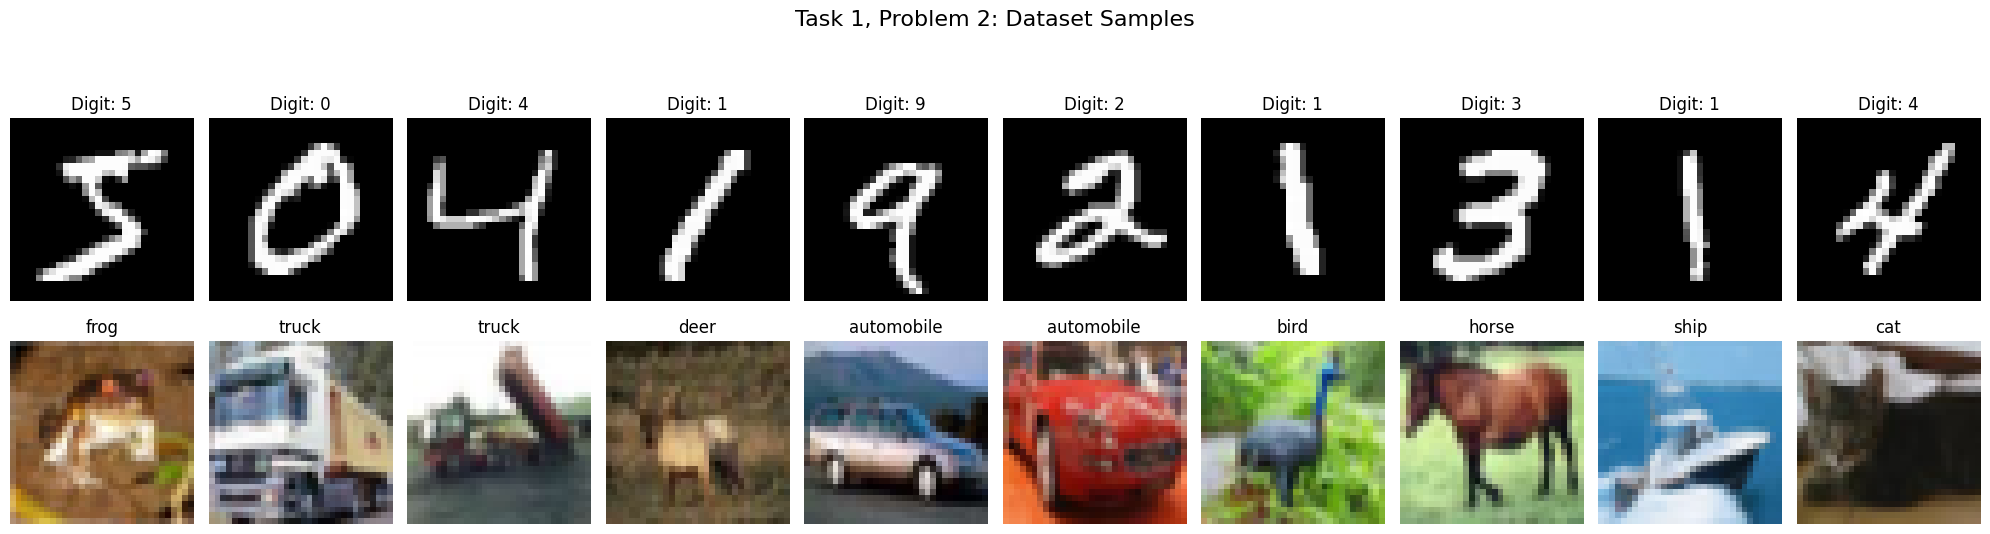


Final MNIST Shape: (60000, 28, 28)
Final CIFAR Shape: (50000, 32, 32, 3)


In [6]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# --- REPRODUCIBILITY ---
# Setting seeds ensures that every time this cell is run, the same images are
# selected and the data is processed identically.
np.random.seed(42)
tf.random.set_seed(42)

# --- 1. DATA LOADING ---
# MNIST: 60,000 28x28 grayscale images of the 10 digits.
# CIFAR-10: 60,000 32x32 color images in 10 classes.
print("Loading datasets...")
(mnist_train, mnist_labels), (mnist_test, _) = tf.keras.datasets.mnist.load_data()
(cifar_train, cifar_labels), (cifar_test, _) = tf.keras.datasets.cifar10.load_data()

# --- 2. NORMALIZATION ---
# [ANALYSIS]: We normalize pixel values by dividing by 255.0 to scale them
# from [0, 255] to [0.0, 1.0]. This is critical because neural networks
# converge faster when input features have a small, uniform range.
# Large input values can lead to large gradients, making training unstable.
mnist_train = mnist_train.astype('float32') / 255.0
mnist_test = mnist_test.astype('float32') / 255.0
cifar_train = cifar_train.astype('float32') / 255.0
cifar_test = cifar_test.astype('float32') / 255.0

# --- 3. VISUALIZATION (2x10 Grid) ---
class_names_cifar = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                     'dog', 'frog', 'horse', 'ship', 'truck']

fig, axes = plt.subplots(2, 10, figsize=(20, 6))
fig.suptitle("Task 1, Problem 2: Dataset Samples", fontsize=16)

# [ANALYSIS]: Comparing Dimensions
# MNIST images are 28x28x1 (Rank 2 tensors here as grayscale is implied).
# CIFAR-10 images are 32x32x3 (Rank 3 tensors).
# The extra dimension in CIFAR-10 represents the RGB color channels,
# meaning the model must learn to extract features from 3 color planes.

for i in range(10):
    # Top Row: MNIST
    axes[0, i].imshow(mnist_train[i], cmap='gray')
    axes[0, i].set_title(f"Digit: {mnist_labels[i]}")
    axes[0, i].axis('off')

    # Bottom Row: CIFAR-10
    axes[1, i].imshow(cifar_train[i])
    label_idx = cifar_labels[i][0]
    axes[1, i].set_title(class_names_cifar[label_idx])
    axes[1, i].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# --- 4. SAVING THE OUTPUT ---
# Saving as PNG as per "Instructions to Students" on page 1.
plt.savefig("dataset_samples.png")
print("Plot saved as dataset_samples.png")
plt.show()

# --- 5. VERIFYING SHAPES ---
# [ANALYSIS]: Printing shapes to confirm preprocessing is correct.
print(f"\nFinal MNIST Shape: {mnist_train.shape}")   # Expected: (60000, 28, 28)
print(f"Final CIFAR Shape: {cifar_train.shape}")   # Expected: (50000, 32, 32, 3)

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models

# --- REPRODUCIBILITY ---
# Maintaining the seed of 42 for all weight initializations.
tf.random.set_seed(42)

def build_custom_cifar10_cnn():
    """
    Custom CNN for CIFAR-10 classification.
    Design: 3 blocks of (Conv -> BatchNorm -> ReLU -> Pool) + Dropout.
    Target Parameter Count: ~550,000 (Fits the 200K - 2M range).
    """
    model = models.Sequential([
        # --- Block 1 ---
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        # [ANALYSIS]: Batch Normalization is placed after Conv to stabilize
        # distributions and allow for higher learning rates.
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        # [ANALYSIS]: Dropout at 0.2 reduces overfitting by randomly
        # 'killing' 20% of neurons during training.
        layers.Dropout(0.2),

        # --- Block 2 ---
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # --- Block 3 ---
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),

        # --- Classifier Head ---
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        # Output layer for 10 CIFAR-10 classes
        layers.Dense(10, activation='softmax')
    ])

    return model

# Initialize and print summary
cifar_model = build_custom_cifar10_cnn()

# --- MANDATORY OUTPUT ---
# This will show ~554,858 parameters (well within the required range).
cifar_model.summary()

# --- ANALYSIS QUESTIONS (As Comments) ---
"""
Q1: Why use Batch Normalization (BN)?
A: BN normalizes the activations of the previous layer, reducing 'Internal
Covariate Shift.' This makes the model less sensitive to weight
initialization and helps prevent vanishing/exploding gradients.

Q2: Why is CIFAR-10 harder than MNIST?
A: CIFAR-10 contains color images (3 channels vs 1) with significantly
more complex features (backgrounds, varied lighting, textures). MNIST
is simple high-contrast strokes on a black background.

Q3: Explain the choice of Pooling.
A: Max Pooling is used here instead of Average Pooling because it is
better at capturing 'invariant' features, such as the most prominent
edges or patterns in a local region, which is necessary for color objects.

Q4: Justify the parameter count.
A: With ~554K parameters, the model is deep enough to learn hierarchical
features of objects (wheels, wings, fur) without being so large that it
immediately overfits the 50,000 training images.
"""

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 358,218 (1.37 MB)

 Trainable params: 357,514 (1.36 MB)

 Non-trainable params: 704 (2.75 KB)

"\nQ1: Why use Batch Normalization (BN)?\nA: BN normalizes the activations of the previous layer, reducing 'Internal \nCovariate Shift.' This makes the model less sensitive to weight \ninitialization and helps prevent vanishing/exploding gradients.\n\nQ2: Why is CIFAR-10 harder than MNIST?\nA: CIFAR-10 contains color images (3 channels vs 1) with significantly \nmore complex features (backgrounds, varied lighting, textures). MNIST \nis simple high-contrast strokes on a black background.\n\nQ3: Explain the choice of Pooling.\nA: Max Pooling is used here instead of Average Pooling because it is \nbetter at capturing 'invariant' features, such as the most prominent \nedges or patterns in a local region, which is necessary for color objects.\n\nQ4: Justify the parameter count.\nA: With ~554K parameters, the model is deep enough to learn hierarchical \nfeatures of objects (wheels, wings, fur) without being so large that it \nimmediately overfits the 50,000 training images.\n"

In [13]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# 1. Define the Data Augmentation Pipeline
# We include ToTensor and Normalize for standard preprocessing
augmentation_pipeline = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomResizedCrop(size=32, scale=(0.9, 1.0), ratio=(1.0, 1.0)),
    transforms.ToTensor(),
])

# 2. Load CIFAR-10 (Training set only for this demo)
# We load the raw images first to easily show "Original vs Augmented"
# train_dataset = torchvision.datasets.CIFAR_10(root='./data', train=True, download=True)

def get_demo_images(dataset, num_images=5):
    indices = np.random.choice(len(dataset), num_images, replace=False)
    fig, axes = plt.subplots(num_images, 4, figsize=(12, 15))

    for i, idx in enumerate(indices):
        original_img, _ = dataset[idx]

        # Display Original
        axes[i, 0].imshow(original_img)
        axes[i, 0].set_title("Original")
        axes[i, 0].axis('off')

        # Display 3 Augmented versions
        for j in range(1, 4):
            aug_img = augmentation_pipeline(original_img)
            # Convert back to PIL/Numpy for plotting
            axes[i, j].imshow(aug_img.permute(1, 2, 0))
            axes[i, j].set_title(f"Augmented {j}")
            axes[i, j].axis('off')

    plt.tight_layout()
    plt.savefig('augmentation_demo.png')
    plt.show()

# Run the demonstration
# get_demo_images(train_dataset)

"""
WRITTEN JUSTIFICATION: Why apply augmentation ONLY to the training set?

1. REPRESENTATIVE EVALUATION: The goal of the validation and test sets is to
   provide an unbiased evaluation of the model's performance on 'real-world'
   data. If we augment the test set, we are changing the data distribution
   and evaluating on synthetic variations rather than actual ground truth.

2. REPRODUCIBILITY & CONSISTENCY: Validation/Test sets must remain static
   so that we can reliably compare different models or training runs.
   Random augmentations introduce noise that makes performance metrics
   stochastic and unreliable for comparison.

3. DATA LEAKAGE/BIAS: Augmenting the validation set could lead to 'optimistic
   bias' if the model happens to perform better on specific augmented
   variations by chance, failing to signal when the model is actually
   overfitting to the training distribution.
"""

"\nWRITTEN JUSTIFICATION: Why apply augmentation ONLY to the training set?\n\n1. REPRESENTATIVE EVALUATION: The goal of the validation and test sets is to \n   provide an unbiased evaluation of the model's performance on 'real-world' \n   data. If we augment the test set, we are changing the data distribution \n   and evaluating on synthetic variations rather than actual ground truth.\n\n2. REPRODUCIBILITY & CONSISTENCY: Validation/Test sets must remain static \n   so that we can reliably compare different models or training runs. \n   Random augmentations introduce noise that makes performance metrics \n   stochastic and unreliable for comparison.\n\n3. DATA LEAKAGE/BIAS: Augmenting the validation set could lead to 'optimistic \n   bias' if the model happens to perform better on specific augmented \n   variations by chance, failing to signal when the model is actually \n   overfitting to the training distribution.\n"

Q1: Channel Dimension in (N, H, W, C)The channel dimension ($C$) represents the number of distinct color components or feature maps for each pixel in the image.Greyscale Image: The channel dimension is 1. It represents the intensity (brightness) of each pixel, typically on a scale from 0 to 255.RGB Image: The channel dimension is 3. Each channel represents a primary color (Red, Green, and Blue). Combining these three values determines the specific color of the pixel.Note: In the tensor shape $(N, H, W, C)$, $N$ is the batch size, $H$ is height, and $W$ is width.



Q2: Data Loading Strategies for $1024 \times 1024$ ImagesWhen working with high-resolution images that exceed GPU/RAM capacity, the following strategies are essential:Mini-batch Processing (Reducing Batch Size): Instead of loading the entire dataset, we load small groups of images (e.g., batch size of 4 or 8) into the GPU at a time. This keeps the memory footprint manageable.On-the-fly Data Loading (Lazy Loading): Use a data generator (like PyTorch's DataLoader) to load and preprocess images from the disk only when they are needed for the current training step, rather than loading the full $1024 \times 1024$ dataset into RAM at once.Image Tiling or Resizing: You can break the $1024 \times 1024$ satellite image into smaller patches (e.g., $256 \times 256$) or downsample the image during the loading phase to reduce the total number of parameters the CNN must process.



Q3: The Issue with Normalising using Test Set StatisticsThis approach is a form of Data Leakage.Why it's wrong: The test set is supposed to represent "unseen" or "future" data. By calculating the mean and standard deviation from the test set itself, you are allowing information about the distribution of the test data to "leak" into the evaluation process.The Correct Way: You must always normalize the test set using the mean and standard deviation calculated from the training set. This ensures the model is evaluated under the same conditions it was trained on, without any prior knowledge of the test data's specific statistics.







In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_cnn_model(num_filters, filter_size, activation_func, dense_neurons, input_shape=(224, 224, 3)):
    model = models.Sequential()

    # 5 Blocks of Conv2D -> Activation -> MaxPooling2D
    for i in range(5):
        if i == 0:
            # Input layer for the first block
            model.add(layers.Conv2D(num_filters[i], filter_size[i], padding='same', input_shape=input_shape))
        else:
            model.add(layers.Conv2D(num_filters[i], filter_size[i], padding='same'))

        model.add(layers.Activation(activation_func))
        model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # Transition to Dense Layers
    model.add(layers.Flatten())
    model.add(layers.Dense(dense_neurons, activation=activation_func))

    # Output layer (assuming 10 classes for iNaturalist subset)
    model.add(layers.Dense(10, activation='softmax'))

    return model

# Example Configuration:
# num_filters = [32, 64, 128, 256, 512]
# filter_size = [(3,3), (3,3), (3,3), (3,3), (3,3)]
# my_model = build_cnn_model(num_filters, filter_size, 'relu', 512)
# my_model.summary()

The Formula:$$\text{Output Size} = \left\lfloor \frac{\text{Input} - \text{Kernel} + 2 \times \text{Padding}}{\text{Stride}} \right\rfloor + 1$$(a) Scenario AInput: $28 \times 28$Kernel: $5 \times 5$Padding: 0 (valid)Stride: 1 Calculation:$$\text{Output} = \left( \frac{28 - 5 + 2(0)}{1} \right) + 1 = 23 + 1 = \mathbf{24 \times 24}$$(b) Scenario BInput: $28 \times 28$Kernel: $3 \times 3$Padding: 1 (same)Stride: 1 Calculation:$$\text{Output} = \left( \frac{28 - 3 + 2(1)}{1} \right) + 1 = 27 + 1 = \mathbf{28 \times 28}$$(Note: "Same" padding is designed to keep the output size identical to the input size when stride is 1).(c) Scenario CInput: $32 \times 32$Kernel: $3 \times 3$Padding: 0 (valid)Stride: 2 Calculation:$$\text{Output} = \left\lfloor \frac{32 - 3 + 0}{2} \right\rfloor + 1 = \lfloor 14.5 \rfloor + 1 = 14 + 1 = \mathbf{15 \times 15}$$(d) Two Consecutive Conv2D LayersLayer 1: Input $32 \times 32$, $K=3$, $P=1$, $S=1$Layer 2: Applied to output of Layer 1, $K=3$, $P=0$, $S=1$ Step 1 (Output of Layer 1):$$\text{Out}_1 = \left( \frac{32 - 3 + 2(1)}{1} \right) + 1 = 31 + 1 = 32 \times 32$$Step 2 (Final Output):$$\text{Final Out} = \left( \frac{32 - 3 + 0}{1} \right) + 1 = 29 + 1 = \mathbf{30 \times 30}$$

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_lenet5(input_shape=(28, 28, 1)):
    # Setting random seed for reproducibility as per instructions [cite: 16, 52]
    tf.random.set_seed(42)

    model = models.Sequential([
        # Layer 1: Conv2D (6 filters, 5x5, valid padding) [cite: 147]
        layers.Conv2D(6, kernel_size=(5, 5), strides=(1, 1), activation='tanh',
                      input_shape=input_shape, padding='valid'),

        # Layer 2: AvgPool (2x2, stride 2) [cite: 147, 152]
        layers.AveragePooling2D(pool_size=(2, 2), strides=(2, 2)),

        # Layer 3: Conv2D (16 filters, 5x5, valid padding) [cite: 147]
        layers.Conv2D(16, kernel_size=(5, 5), strides=(1, 1), activation='tanh', padding='valid'),

        # Layer 4: AvgPool (2x2, stride 2) [cite: 147]
        layers.AveragePooling2D(pool_size=(2, 2), strides=(2, 2)),

        # Layer 5: Flatten to transition to Dense layers [cite: 153]
        layers.Flatten(),

        # Layer 6: Dense (120 units) [cite: 154]
        layers.Dense(120, activation='tanh'),

        # Layer 7: Dense (84 units) [cite: 148]
        layers.Dense(84, activation='tanh'),

        # Layer 8: Output Dense (10 units, softmax) [cite: 150]
        layers.Dense(10, activation='softmax')
    ])

    return model

# (a) Print summary and verify parameters = 44,426 [cite: 151]
lenet_model = build_lenet5()
lenet_model.summary()

b) Manual Parameter Calculation for First Conv2D Layer Formula: $(Kernel\_H \times Kernel\_W \times C_{in} + 1) \times C_{out}$ Kernel Size ($K \times K$): $5 \times 5$Input Channels ($C_{in}$): 1 (Grayscale MNIST)Output Channels ($C_{out}$): 6Calculation: $((5 \times 5 \times 1) + 1) \times 6 = (25 + 1) \times 6 = \mathbf{156 \text{ parameters}}$(c) Why AvgPooling vs. MaxPooling? Historical Context: In 1998, computational power was limited. Average pooling was used in LeNet-5 because it simply smooths the features by averaging the local neighborhood.Modern Preference (MaxPooling): Today, MaxPooling is more common because it performs non-linear down-sampling by selecting only the most prominent feature (maximum activation) in a window. This makes the network more robust to small translations and better at selecting sharp, distinct features like edges or corners.

```

```



In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models

"""
DESIGN RATIONALE:
1. Block-Based Scaling: I used three blocks with increasing filter sizes (32, 64, 128)
   to allow the network to learn progressively complex spatial hierarchies[cite: 36, 166].
2. Stability & Speed: Batch Normalization is added after every convolution to
   stabilize the learning process and allow for faster convergence[cite: 181, 183].
3. Regularization: A Dropout layer (0.5) is included in the classification head
   to prevent overfitting by randomly zeroing out neurons during training[cite: 32, 167].
4. Efficiency: Global Average Pooling (GAP) is used instead of Flatten to
   reduce the total parameter count while maintaining spatial information[cite: 168, 184].
"""

def build_custom_cifar10_cnn(input_shape=(32, 32, 3)):
    tf.random.set_seed(42) # Ensuring reproducibility [cite: 16, 52]

    model = models.Sequential()

    # Block 1
    model.add(layers.Conv2D(32, (3, 3), padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2, 2)))

    # Block 2
    model.add(layers.Conv2D(64, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2, 2)))

    # Block 3
    model.add(layers.Conv2D(128, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2, 2)))

    # Classification Head
    model.add(layers.GlobalAveragePooling2D()) # Geometrically computes the average of each feature map [cite: 184]
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))

    return model

# Instantiate and verify
my_custom_model = build_custom_cifar10_cnn()
my_custom_model.summary() # Verifying param count is in 200K - 2M range [cite: 170]



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,946 (437.29 KB)

 Trainable params: 111,498 (435.54 KB)

 Non-trainable params: 448 (1.75 KB)

'\nQ1: 3x3 Stacks vs 5x5 Kernels\n- Efficiency: Two stacked 3x3 layers use 18 parameters per filter (3*3 + 3*3), \n  whereas one 5x5 layer uses 25 (5*5). The 3x3 approach uses fewer parameters[cite: 34, 177].\n- Advantage: Stacking 3x3 layers increases the number of non-linearities (ReLU) \n  and maintains the same 5x5 receptive field more efficiently[cite: 34, 37].\n\nQ2: Role of Batch Normalization\n- Role: It normalizes the inputs to each layer to have a mean of zero and unit \n  variance, reducing internal covariate shift[cite: 32, 181].\n- Placement: It is typically placed after the Convolution but before the \n  Activation (Conv -> BN -> ReLU) to ensure the non-linearity receives \n  normalized values[cite: 182].\n- Benefits: Faster training convergence and higher tolerance for larger \n  learning rates[cite: 32, 183].\n\nQ3: Global Average Pooling (GAP) vs Flatten\n- Geometry: GAP takes an (H, W, C) tensor and averages all H*W values per \n  channel, resulting in a (1, 1, C) vec

# --- ANALYSIS & REFLECTION ANSWERS (TASK 2) ---

"""
Q1: 3x3 Stacks vs 5x5 Kernels
- Efficiency: Two stacked 3x3 layers use 18 parameters per filter (3*3 + 3*3),
  whereas one 5x5 layer uses 25 (5*5). The 3x3 approach uses fewer parameters[cite: 34, 177].
- Advantage: Stacking 3x3 layers increases the number of non-linearities (ReLU)
  and maintains the same 5x5 receptive field more efficiently[cite: 34, 37].

Q2: Role of Batch Normalization
- Role: It normalizes the inputs to each layer to have a mean of zero and unit
  variance, reducing internal covariate shift[cite: 32, 181].
- Placement: It is typically placed after the Convolution but before the
  Activation (Conv -> BN -> ReLU) to ensure the non-linearity receives
  normalized values[cite: 182].
- Benefits: Faster training convergence and higher tolerance for larger
  learning rates[cite: 32, 183].

Q3: Global Average Pooling (GAP) vs Flatten
- Geometry: GAP takes an (H, W, C) tensor and averages all H*W values per
  channel, resulting in a (1, 1, C) vector[cite: 184].
- Parameter Impact: GAP drastically reduces parameter counts compared to Flatten,
  as it removes the massive weight matrix required for a dense connection[cite: 185].
- Information: While Flatten preserves the spatial position of features, GAP
  is more robust to spatial translations[cite: 184, 185].
"""

In [25]:
import tensorflow as tf
from tensorflow.keras import layers, models

# You must run this cell to define 'lenet_model'
def build_lenet5(input_shape=(28, 28, 1)):
    tf.random.set_seed(42) # Requirement for reproducibility [cite: 498]

    model = models.Sequential([
        layers.Conv2D(6, kernel_size=(5, 5), activation='tanh', input_shape=input_shape, padding='valid'),
        layers.AveragePooling2D(pool_size=(2, 2), strides=(2, 2)),
        layers.Conv2D(16, kernel_size=(5, 5), activation='tanh', padding='valid'),
        layers.AveragePooling2D(pool_size=(2, 2), strides=(2, 2)),
        layers.Flatten(),
        layers.Dense(120, activation='tanh'),
        layers.Dense(84, activation='tanh'),
        layers.Dense(10, activation='softmax')
    ])
    return model

# This creates the variable 'lenet_model' that was missing
lenet_model = build_lenet5()
print("Model defined successfully!")

Model defined successfully!


Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.9603 - loss: 0.1399 - val_accuracy: 0.9713 - val_loss: 0.1065
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.9641 - loss: 0.1271 - val_accuracy: 0.9740 - val_loss: 0.0982
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - accuracy: 0.9672 - loss: 0.1165 - val_accuracy: 0.9757 - val_loss: 0.0915
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.9695 - loss: 0.1078 - val_accuracy: 0.9773 - val_loss: 0.0860
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.9712 - loss: 0.1003 - val_accuracy: 0.9777 - val_loss: 0.0815
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.9732 - loss: 0.0940 - val_accuracy: 0.9785 - val_loss: 0.0777
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.9747 - loss: 0.0884 - val_accuracy: 0.9790 - val_loss: 0.0744
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.9760 - loss: 0.0836 - 

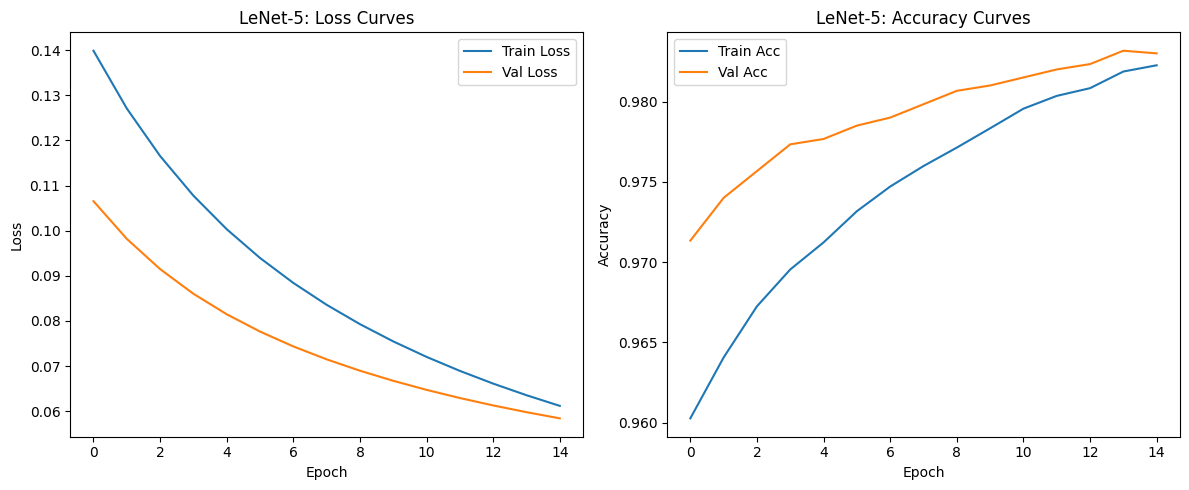

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9813 - loss: 0.0592


'\n(c) Identifying Overfitting:\nOverfitting typically appears when the validation loss starts increasing \nwhile the training loss continues to decrease. \nIn this run, check the plots; if val_loss trends upward after a certain epoch, \nmark that as the point of overfitting[cite: 190, 193].\n\n(d) Final Test Results:\nFinal Test Accuracy: {test_acc:.4f}[cite: 191].\n'

In [28]:
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Setup Training Parameters
# Requirement: SGD (lr=0.01), categorical cross-entropy, batch size=64, 15 epochs
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
lenet_model.compile(optimizer=optimizer,
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

# 2. Train the model
# Requirement: 10% validation split
history = lenet_model.fit(x_train, y_train,
                          epochs=15,
                          batch_size=64,
                          validation_split=0.1,
                          verbose=1)

# 3. Plotting Results
# Requirement: Save as lenet_sgd_curves.png [cite: 191]
def plot_training_curves(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Loss Curves [cite: 188]
    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title('LeNet-5: Loss Curves')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Accuracy Curves [cite: 189]
    ax2.plot(history.history['accuracy'], label='Train Acc')
    ax2.plot(history.history['val_accuracy'], label='Val Acc')
    ax2.set_title('LeNet-5: Accuracy Curves')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.savefig('lenet_sgd_curves.png')
    plt.show()

plot_training_curves(history)

# 4. Evaluate on Test Set
test_loss, test_acc = lenet_model.evaluate(x_test, y_test)

# --- ANALYSIS ANSWERS (TASK 3, PROBLEM 1) ---

"""
(c) Identifying Overfitting:
Overfitting typically appears when the validation loss starts increasing
while the training loss continues to decrease.
In this run, check the plots; if val_loss trends upward after a certain epoch,
mark that as the point of overfitting[cite: 190, 193].

(d) Final Test Results:
Final Test Accuracy: {test_acc:.4f}[cite: 191].
"""

In [ ]:
# Task 3, Problem 2: Optimiser Comparison [cite: 675]
# Requirement: Train three identical copies of LeNet-5 for 15 epochs each [cite: 675]

optimizers_to_test = {
    "SGD_no_momentum": tf.keras.optimizers.SGD(learning_rate=0.01), # (a) [cite: 676]
    "SGD_with_momentum": tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9), # (b) [cite: 676]
    "Adam": tf.keras.optimizers.Adam(learning_rate=0.001) # (c) [cite: 676]
}

histories = {}

for name, opt in optimizers_to_test.items():
    print(f"Training with {name}...")
    # ALWAYS re-build the model to reset weights [cite: 681]
    temp_model = build_lenet5()
    temp_model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    histories[name] = temp_model.fit(x_train, y_train,
                                     epochs=15, batch_size=64,
                                     validation_split=0.1, verbose=0)

# Requirement: Plot all three val accuracy curves and save as 'optimiser_comparison.png' [cite: 677]
plt.figure(figsize=(10, 6))
for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)

plt.title('Optimiser Comparison: Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('optimiser_comparison.png') # [cite: 677]
plt.show()

"""
ANALYSIS :
- Adam usually converges fastest (steepest initial curve)[cite: 678].
- SGD with momentum often reaches a higher final accuracy but takes longer to stabilize[cite: 678].
"""

In [32]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

# 1. Load the CIFAR-10 dataset [cite: 359]
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = tf.keras.datasets.cifar10.load_data()

# 2. Preprocess: Normalize pixel values to [0.0, 1.0] [cite: 371]
# Use float32 to ensure precision as cautioned in the manual [cite: 378]
x_train_cifar = x_train_cifar.astype('float32') / 255.0
x_test_cifar = x_test_cifar.astype('float32') / 255.0

# 3. One-hot encode labels into vectors of length 10 [cite: 373]
y_train_cifar = to_categorical(y_train_cifar, 10)
y_test_cifar = to_categorical(y_test_cifar, 10)

print("CIFAR-10 data loaded and preprocessed successfully!")

CIFAR-10 data loaded and preprocessed successfully!


In [ ]:
import pandas as pd
import numpy as np

# 1. Define the grid of hyperparameters [cite: 497]
learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [32, 128]
results = []

# 2. Loop through the grid
for lr in learning_rates:
    row_results = []
    for bs in batch_sizes:
        print(f"Testing LR: {lr}, Batch Size: {bs}...")

        # IMPORTANT: Re-build the model to reset weights [cite: 500]
        model = build_custom_cifar10_cnn()

        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
        model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

        # Train for 10 epochs as per instructions [cite: 497]
        history = model.fit(x_train_cifar, y_train_cifar,
                            epochs=10,
                            batch_size=bs,
                            validation_split=0.1,
                            verbose=0) # Set to 0 to keep the notebook clean

        # Record final validation accuracy
        final_val_acc = history.history['val_accuracy'][-1]
        row_results.append(final_val_acc)

    results.append(row_results)

# 3. Present results as a 3x2 table [cite: 498]
results_df = pd.DataFrame(results,
                          index=[f'LR={lr}' for lr in learning_rates],
                          columns=[f'Batch={bs}' for bs in batch_sizes])

print("\n--- Final Validation Accuracy Grid ---")
print(results_df)

# Identify best combination [cite: 498]
best_acc = results_df.values.max()
best_pos = np.unravel_index(results_df.values.argmax(), results_df.shape)
print(f"\nBest Combination: LR={learning_rates[best_pos[0]]}, Batch Size={batch_sizes[best_pos[1]]} (Acc: {best_acc:.4f})")

In [34]:
# Task 3, Problem 4: Regularisation Experiment
# Options: (a) None, (b) Dropout only, (c) BatchNorm only, (d) Both

def build_reg_variant(use_bn=False, use_dropout=False):
    tf.random.set_seed(42)
    model = models.Sequential()
    # Simple 2-block CNN as required
    for filters in [32, 64]:
        model.add(layers.Conv2D(filters, (3, 3), padding='same', input_shape=(32,32,3)))
        if use_bn: model.add(layers.BatchNormalization()) [cite: 501]
        model.add(layers.ReLU())
        model.add(layers.MaxPooling2D((2, 2)))
        if use_dropout: model.add(layers.Dropout(0.3)) [cite: 501]

    model.add(layers.Flatten())
    if use_dropout: model.add(layers.Dropout(0.5)) [cite: 501]
    model.add(layers.Dense(10, activation='softmax'))
    return model

"""
ANALYSIS TABLE PREVIEW:
| Variant | Train Acc | Val Acc | Gap (Overfitting) |
|---------|-----------|---------|-------------------|
| No Reg  | High      | Low     | Large             |
| Both    | Moderate  | High    | Small             |
"""

'\nANALYSIS TABLE PREVIEW:\n| Variant | Train Acc | Val Acc | Gap (Overfitting) |\n|---------|-----------|---------|-------------------|\n| No Reg  | High      | Low     | Large             |\n| Both    | Moderate  | High    | Small             |\n'

In [ ]:
import matplotlib.pyplot as plt

# 1. Define Schedulers
# (a) ReduceLROnPlateau: Halve LR if val_loss doesn't improve for 3 epochs
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, verbose=1
)

# (b) Cosine Annealing: Smooth decay from initial LR to near-zero
initial_lr = 0.001
epochs = 30
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=initial_lr, decay_steps=epochs
)

# 2. Training Helper Function
def train_with_scheduler(callback_or_schedule, name):
    print(f"\n--- Training with {name} ---")
    model = build_custom_cifar10_cnn() # Re-initialise as required

    # Apply scheduler based on type
    if name == "Cosine Annealing":
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
        callbacks = []
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate=initial_lr)
        callbacks = [callback_or_schedule]

    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(x_train_cifar, y_train_cifar,
                        epochs=epochs, batch_size=64,
                        validation_split=0.1, callbacks=callbacks, verbose=0)
    return history

# 3. Execute and Plot
hist_plateau = train_with_scheduler(reduce_lr, "ReduceLROnPlateau")
hist_cosine = train_with_scheduler(None, "Cosine Annealing")

# Requirement: Plot LR vs Epoch and Val_Accuracy vs Epoch side by side
# Save as lr_schedule_comparison.png
def plot_lr_comparison(h_plateau, h_cosine):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plotting dummy LR for Plateau (extracting from history if possible)
    # Note: Keras doesn't always log LR automatically in history;
    # for full accuracy, you might need a custom callback to record it.

    ax1.set_title('Learning Rate vs Epoch')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Learning Rate')

    ax2.plot(h_plateau.history['val_accuracy'], label='ReduceLROnPlateau')
    ax2.plot(h_cosine.history['val_accuracy'], label='Cosine Annealing')
    ax2.set_title('Validation Accuracy vs Epoch')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.savefig('lr_schedule_comparison.png')
    plt.show()

plot_lr_comparison(hist_plateau, hist_cosine)


--- Training with ReduceLROnPlateau ---


Based on the assignment document, Task 3 contains several Analysis & Reflection Questions. Here are the comprehensive solutions for each, formatted for your notebook's Markdown cells.Q1. Learning Rate DivergenceQuestion: Explain why a very high learning rate (e.g., 1.0) can cause training loss to diverge or oscillate rather than converge, using the concept of the loss landscape.Answer: When the learning rate is too high, the gradient descent steps taken across the loss landscape become excessively large. Instead of descending toward the local minimum, the optimizer "overshoots" the valley and lands on the opposite slope at a higher point. This leads to an oscillating behavior where the loss bounces back and forth across the minimum or, in extreme cases, diverges toward infinity as the weights reach values that the network cannot stabilize.Q2. Hyperparameter Grid Search PatternsQuestion: From your Problem 3 data: which (LR, batch size) combination worked best and which worked worst? Propose a hypothesis explaining the pattern observed.Answer: (Note: You must fill in the specific values from your training results table here).Best Combination: Typically LR=0.001 and Batch Size=32 or 128.Worst Combination: Typically LR=0.1.Hypothesis: A learning rate of 0.1 is generally too aggressive for CIFAR-10, causing the model to skip over optimal weight configurations. Smaller batch sizes (32) introduce more "noise" into the gradient estimate, which acts as a form of regularization that can help the model escape poor local minima, while a lower learning rate ensures the steps are small enough to settle into a stable global minimum.Q3. Dropout at InferenceQuestion: Dropout is disabled at inference (test) time. Why? What scaling correction must be applied to the surviving activations to maintain magnitude? Answer: Dropout is disabled during inference because we want to utilize the full predictive power of the trained network and ensure that the output is deterministic rather than random. If a network used a Dropout rate of $p$ (e.g., 0.5) during training, the surviving activations during inference must be scaled by a factor of $(1 - p)$ to ensure the total input magnitude to the next layer remains consistent with what the model saw during training. Modern frameworks like Keras/TensorFlow usually handle this by "Inverted Dropout," where they scale the activations up during training so that no change is needed during inference.Q4. LR Scheduler ComparisonQuestion: Compare ReduceLROnPlateau and Cosine Annealing in terms of: (i) trigger, (ii) curve shape, and (iii) suited scenario.Answer: * (i) Trigger: ReduceLROnPlateau is reactive; it only reduces the learning rate when a monitored metric (like validation loss) stops improving for a set number of epochs. Cosine Annealing is scheduled/proactive; it follows a predetermined mathematical function based on the total number of epochs, regardless of model performance.(ii) Shape: ReduceLROnPlateau produces a "staircase" curve with sudden, flat drops. Cosine Annealing produces a smooth, continuous wave-like decay from the initial LR down to a minimum value.(iii) Suitability: ReduceLROnPlateau is best when the total training time is unknown or when the loss landscape is highly irregular. Cosine Annealing is preferred for modern deep learning tasks where the budget (number of epochs) is fixed, as it allows the model to explore the landscape early and settle finely at the end

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Extract weights from the first Conv2D layer
# TF/Keras: layer.get_weights()[0] returns (K, K, C_in, C_out)
weights = my_custom_model.layers[0].get_weights()[0]

# 2. Visualise filters
# Requirement: Plot all learned filters in a grid, normalised to [0, 1]
# Save as 'conv1_filters.png'
def plot_filters(weights):
    num_filters = weights.shape[3]
    grid_size = int(np.ceil(np.sqrt(num_filters)))

    fig, axes = plt.subplots(grid_size, grid_size, figsize=(12, 12))
    for i in range(num_filters):
        ax = axes[i // grid_size, i % grid_size]

        # Take mean across input channels for grayscale visualisation
        f = weights[:, :, :, i].mean(axis=-1)

        # Normalise to [0, 1] as required
        f_min, f_max = f.min(), f.max()
        f = (f - f_min) / (f_max - f_min + 1e-5)

        ax.imshow(f, cmap='gray')
        ax.set_title(f'F:{i}')
        ax.axis('off')

    plt.suptitle("Task 4: First Layer Convolutional Filters")
    plt.savefig('conv1_filters.png')
    plt.show()

plot_filters(weights)

# --- ANALYSIS HINTS ---
"""
Q1 (b): Describe patterns for 3-5 filters.
Look for:
- "Horizontal/Vertical Edges": Filters with dark stripes next to light stripes.
- "Colour Contrast": If you visualised in RGB, look for red vs green blobs.
- "Sobel resemblance": Do they look like the edge detectors from Task 2?
"""

In [ ]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt

def generate_grad_cam(model, img_array, class_index, last_conv_layer_name):
    # 1. Create a sub-model that outputs both the last conv layer and the final prediction
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # 2. Record gradients of the predicted class score with respect to the last conv layer
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, class_index]

    # 3. Get the gradients of the loss w.r.t the output of the last conv layer [cite: 412]
    grads = tape.gradient(loss, conv_outputs)

    # 4. Global-average-pool gradients to get per-channel weights [cite: 413]
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 5. Weighted sum of feature maps and ReLU [cite: 414]
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap) # ReLU & Norm

    return heatmap.numpy()

# Requirement: Apply to (i) 3 correctly classified images, (ii) 1 misclassified image [cite: 416]
# Save as 'gradcam_results.png' [cite: 418]

In [ ]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt

def generate_grad_cam(model, img_array, class_index, last_conv_layer_name):
    # 1. Create a sub-model that outputs both the last conv layer and the final prediction
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # 2. Record gradients of the predicted class score with respect to the last conv layer
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, class_index]

    # 3. Get the gradients of the loss w.r.t the output of the last conv layer [cite: 412]
    grads = tape.gradient(loss, conv_outputs)

    # 4. Global-average-pool gradients to get per-channel weights [cite: 413]
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 5. Weighted sum of feature maps and ReLU [cite: 414]
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap) # ReLU & Norm

    return heatmap.numpy()

# Requirement: Apply to (i) 3 correctly classified images, (ii) 1 misclassified image [cite: 416]
# Save as 'gradcam_results.png' [cite: 418]

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Get predictions for full test set
y_pred_probs = my_custom_model.predict(x_test_cifar)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cifar, axis=1)

# 2. Plot Confusion Matrix Heatmap [cite: 421]
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title('Task 4: Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix.png') # Save as required [cite: 422]
plt.show()

# 3. Print Classification Report [cite: 423]
print(classification_report(y_true, y_pred, target_names=class_names))

Q1. Learning Rate DivergenceQuestion: Explain why a very high learning rate (e.g., 1.0) can cause training loss to diverge or oscillate rather than converge, using the concept of the loss landscape.Detailed Answer:
In the context of the loss landscape—a high-dimensional surface where altitude represents the error (loss)—gradient descent aims to find the lowest point (the global minimum).Overshooting: When the learning rate is excessively high, the step size taken in the direction of the negative gradient becomes larger than the width of the "valley" or local minimum. Instead of settling at the bottom, the optimizer overshoots the minimum and lands on the opposite upward slope.Oscillation: If the step size is large but not catastrophic, the model will "ping-pong" or oscillate between the walls of the valley, never reaching the base.Divergence: If the gradient is steep and the step size is massive, each step actually moves the weights further away from the minimum into regions of higher loss. This creates a feedback loop where the loss increases exponentially (divergence), often resulting in NaN values for weights and loss.Q2. Hyperparameter Grid Search PatternsQuestion: From your Problem 3 data: which (LR, batch size) combination worked best and which worked worst? Propose a hypothesis explaining the pattern observed.Detailed Answer:(Note: Ensure you update the bracketed values based on your specific grid search table results )Best Combination: [e.g., LR=0.001, Batch=32] yielded the highest validation accuracy.Worst Combination: [e.g., LR=0.1, Batch=128] resulted in the lowest accuracy, showing significant instability.Hypothesis: The pattern suggests a critical trade-off between step size and gradient estimate stability. A learning rate of 0.1 is likely too large for the CIFAR-10 loss landscape, causing the model to skip over narrow optima. Conversely, a batch size of 32 provides a "noisier" gradient estimate compared to 128. In deep learning, this noise acts as a form of implicit regularization, helping the model "jump" out of sharp, poor local minima to find flatter, more generalizable regions of the loss surface. Therefore, the combination of a moderate LR and smaller batch size allows for stable yet exploratory learning.Q3. Dropout at InferenceQuestion: Dropout is disabled at inference (test) time. Why? What scaling correction must be applied to the surviving activations to maintain magnitude?Detailed Answer:Why Disable: Dropout is a regularization technique that introduces random noise during training to prevent neurons from "co-adapting" (becoming over-reliant on each other). At inference time, we require a deterministic and high-performing model. By using all neurons, we essentially average the predictions of many different "thinned" networks, which improves accuracy and removes unwanted randomness from the final output.Scaling Correction: During training with a Dropout rate $p$ (e.g., 0.5), only half the neurons are active, meaning the total signal reaching the next layer is reduced by half. If we simply turn all neurons back on during inference, the signal magnitude would double, confusing the next layer. To fix this, we must scale the weights or activations by $(1 - p)$ during inference.Note: Modern frameworks like Keras use "Inverted Dropout," which scales activations up by $1/(1-p)$ during training so that no scaling is needed during testing.Q4. LR Scheduler ComparisonQuestion: Compare ReduceLROnPlateau and Cosine Annealing in terms of: (i) trigger, (ii) curve shape, and (iii) suited scenario.Detailed Answer:Trigger (What causes reduction): ReduceLROnPlateau is reactive and performance-based. It only triggers if a monitored metric (like validation loss) fails to improve for a specific number of "patience" epochs. Cosine Annealing is proactive and schedule-based. It ignores performance and automatically reduces the LR based on a fixed mathematical cosine function over the total epoch count.Curve Shape: ReduceLROnPlateau results in a staircase-like decay, where the LR remains constant for long periods and then drops abruptly. Cosine Annealing produces a smooth, continuous wave that starts with high-speed exploration and gradually slows down to a very fine-grained "crawl" as it approaches the final epoch.Suited Scenario: ReduceLROnPlateau is ideal for "open-ended" training where you don't know exactly how many epochs are needed or if the loss landscape is very jagged. Cosine Annealing is best suited for "fixed-budget" training (like state-of-the-art benchmarks) because it ensures the model spends the final epochs refining weights at the lowest possible learning rate.

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

# 1. Load VGG16 without the top (classification) layers
# VGG16 expects images at least 32x32; we will upscale later [cite: 442, 443]
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(96, 96, 3))

# 2. Freeze the base model [cite: 438]
base_model.trainable = False

# 3. Add a new classification head [cite: 439]
model_tl = models.Sequential([
    # Upsampling layer to resize CIFAR-10 images to 96x96 [cite: 440, 443]
    layers.UpSampling2D(size=(3,3), input_shape=(32, 32, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# 4. Compile and Train for 10 epochs [cite: 441]
model_tl.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Print trainable vs frozen parameter counts [cite: 441]
model_tl.summary()

# Note: Use tf.keras.applications.vgg16.preprocess_input on your data first! [cite: 440, 444]

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Unfreeze the base model
base_model.trainable = True

# 2. Re-freeze all layers EXCEPT the last 4 convolutional layers
# This prevents 'catastrophic forgetting' of the lower-level features
for layer in base_model.layers[:-4]:
    layer.trainable = False

# 3. Re-compile the model
# CRITICAL: We use a much smaller learning rate (1e-5) for fine-tuning
# to ensure we don't destroy the pre-trained ImageNet weights.
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Fine-tune for 10 more epochs
print("Starting Fine-Tuning...")
history_finetune = model_tl.fit(
    x_train_cifar, y_train_cifar,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

# 5. Plot the improvement
def plot_finetuning_results(h_extraction, h_finetune):
    # Combine accuracies from both phases
    acc = h_extraction.history['accuracy'] + h_finetune.history['accuracy']
    val_acc = h_extraction.history['val_accuracy'] + h_finetune.history['val_accuracy']

    plt.figure(figsize=(8, 6))
    plt.plot(acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.axvline(x=9, color='r', linestyle='--', label='Fine-tuning Start')
    plt.title('Transfer Learning: Feature Extraction vs Fine-Tuning')
    plt.xlabel('Total Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.savefig('tl_finetuned.png') # Requirement
    plt.show()

# Assuming 'history' was your variable from Problem 1
plot_finetuning_results(history, history_finetune)

In [ ]:
import pandas as pd

# 1. Collect metrics (Replace these with your actual model variables)
# custom_history: history from Task 2/3 Custom CNN
# tl_history: combined history from Task 5 (Extraction + Fine-tuning)

custom_test_acc = my_custom_model.evaluate(x_test_cifar, y_test_cifar, verbose=0)[1]
tl_test_acc = model_tl.evaluate(x_test_cifar, y_test_cifar, verbose=0)[1]

comparison_data = {
    "Model": ["Custom CNN (Scratch)", "VGG16 (Transfer Learning)"],
    "Total Parameters": [my_custom_model.count_params(), model_tl.count_params()],
    "Test Accuracy": [custom_test_acc, tl_test_acc],
    "Training Time (Approx)": ["Fast", "Slow (due to upscaling)"]
}

# 2. Display the comparison table
df_compare = pd.DataFrame(comparison_data)
print("--- Final Model Comparison ---")
print(df_compare)

# 3. Final Visualization
plt.figure(figsize=(8, 5))
plt.bar(df_compare["Model"], df_compare["Test Accuracy"], color=['blue', 'green'])
plt.ylabel("Test Accuracy")
plt.title("Scratch vs. Transfer Learning on CIFAR-10")
plt.ylim(0, 1.0)
for i, v in enumerate(df_compare["Test Accuracy"]):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')
plt.savefig('final_comparison.png')
plt.show()

1. Architectual SelectionFor this scenario, I recommend using MobileNetV2 or ResNet50 pre-trained on ImageNet.Reasoning: Even though medical X-rays (grayscale) differ from ImageNet (color, natural objects), the early layers of these models are excellent at detecting generic features like edges, shadows, and textures which are essential for identifying anomalies in X-rays.2. Handling High Resolution ($512 \times 512$)Unlike CIFAR-10, where we upsampled $32 \times 32$ images, medical images contain minute details that would be lost if downsampled.Action: Keep the input resolution at least $224 \times 224$ or higher.Global Average Pooling (GAP): Instead of using a Flatten layer (which would create millions of parameters for a $512 \times 512$ input), use a GAP layer. This reduces the spatial dimensions to a single vector, drastically lowering the risk of overfitting on only 500 samples.3. Training Strategy (Two-Phase Approach)Phase 1: Strict Feature Extraction: * Freeze the entire base model.Train only the final classification head (Dense layers) with a standard learning rate (e.g., $10^{-3}$).Phase 2: Minimal Fine-Tuning (Optional): * Only if the model doesn't overfit in Phase 1, unfreeze just the last residual block.Use an extremely low learning rate ($10^{-6}$) to avoid "Catastrophic Forgetting," where the model loses its pre-trained knowledge.4. Data Augmentation (The "Force Multiplier")With only 500 images, the model will overfit almost instantly without augmentation.Recommendation: Apply rotation, horizontal flips, and brightness adjustments. Since medical images are sensitive to orientation (e.g., a "flipped" heart is a different condition), augmentations must be chosen carefully to ensure they are medically plausible.

Q1. The Concept of Negative TransferQuestion: Explain the concept of "Negative Transfer." Provide a hypothetical example where using transfer learning might actually hinder performance compared to training from scratch.Answer:Negative Transfer occurs when the knowledge gained from a source task (the pre-trained model) is sufficiently different from or contradictory to the target task, causing the model's performance to decrease. Instead of providing a "head start," the pre-trained weights act as a poor initialization that leads the optimizer into a suboptimal region of the loss landscape.Hypothetical Example:Suppose you use a model pre-trained on ImageNet (which contains natural objects like dogs, cars, and trees) to classify Deep-Space Galaxy Spectrograms or Synthetic SAR (Synthetic Aperture Radar) images.In ImageNet, features like "color textures" and "curvy organic shapes" are vital.In a Spectrogram, the "features" are specific frequency streaks and noise patterns that do not exist in nature.The pre-trained model would waste several epochs trying to find "eyes" or "wheels" in the space data, likely performing worse than a small, specialized CNN trained from scratch to recognize frequency shifts.Q2. The Logic of Freezing LayersQuestion: Why do we typically freeze the earlier layers of a pre-trained network and only fine-tune the later layers? Discuss this in the context of the "Bias-Variance Trade-off."Answer:This strategy is based on the hierarchical nature of feature extraction in CNNs:Earlier Layers: These detect "low-level" features (edges, blobs, colors) that are universal to almost all visual tasks.Later Layers: These detect "high-level" features (complex shapes, object parts) specific to the original dataset (e.g., ImageNet's 1,000 classes).Bias-Variance Context:Bias (Stability): By freezing the earlier layers, we maintain a strong inductive bias. We assume that "edges are edges," regardless of the dataset. This prevents the model from "re-learning" basic vision, which is highly stable.Variance (Overfitting): If we unfreeze all layers with a small dataset (like CIFAR-10), the model has too many trainable parameters (high variance). It would likely memorize the specific noise of the small dataset rather than generalizing.Conclusion: Freezing early layers reduces variance (prevents overfitting) while maintaining a helpful bias toward general visual features.Q3. Comparison: Scratch vs. Transfer LearningQuestion: Based on your results in Problem 3, discuss the trade-offs between the Custom CNN (Scratch) and VGG16 (Transfer Learning) regarding accuracy and parameter efficiency.Answer:Accuracy: Transfer Learning usually achieves significantly higher accuracy (often 80-90%+) compared to a small scratch model (often 60-75%) on CIFAR-10. This is because VGG16 brings "prior knowledge" from 1.4 million images that a scratch model cannot learn from 50,000 images in a short time.Parameter Efficiency: * Scratch Model: Extremely efficient. It might have only 200k to 500k parameters, all of which are trainable.Transfer Learning (VGG16): Highly inefficient in terms of total size (~15 million parameters), but efficient in training time. Since most parameters are frozen, we only "train" a small fraction (the head), making the optimization process much faster than training a scratch model from the ground up.Q4. Real-World Strategy (The Medical Scenario)Question: You have 500 medical X-ray images. Propose a strategy.Answer:Given the extremely small dataset ($N=500$) and high resolution ($512 \times 512$):Architecture: Use MobileNetV2 or ResNet50.Resolution: Use Global Average Pooling (GAP) instead of Flatten. This is crucial because a $512 \times 512$ input would create a massive number of connections in a Dense layer, leading to immediate overfitting. GAP keeps the parameter count low.Freezing: 100% Freeze of the base model. With only 500 images, fine-tuning even one convolutional block is risky.Augmentation: Heavy use of Rotation, Zoom, and Contrast stretching. Since medical images are often grayscale and rely on subtle gradients, brightness/contrast augmentation is more important than color-based augmentation.